# Table of Contents
1. Data Wrangling
2. Descriptive Statistics
3. Hypothesis Testing - H1

### Import the libraries

In [3]:
import pandas as pd
import numpy as np

In [5]:
# File paths

FILE1_PATH = "/Users/macbookpro/Downloads/FOR_ANALYSIS_coded_wide.xlsx"
FILE2_PATH = "/Users/macbookpro/Downloads/Anthropic v1 - Task 2 Prompt inj DATA.xlsx"
OUTPUT_PATH = "/Users/macbookpro/Downloads/File3_merged_cleaned.xlsx"

In [5]:
%pip install openpyxl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [openpyxl]1/2 [openpyxl]
Note: you may need to restart the kernel to use updated packages.


## 1. Data Wrangling

### 1.1 Load files and report row counts

In [7]:
# 1. Load datasets
df_analysis = pd.read_excel(FILE1_PATH)
df_anthropic = pd.read_excel(FILE2_PATH)

# 2. Add the source_file tag to each dataframe
df_analysis["source_file"] = "FOR_ANALYSIS_coded_wide"
df_anthropic["source_file"] = "Anthropic_v1"

# Output row counts
print(f"FOR_ANALYSIS_coded_wide.xlsx rows: {len(df_analysis)}")
print(f"Anthropic v1 - Task 2 Prompt inj DATA.xlsx rows: {len(df_anthropic)}")

FOR_ANALYSIS_coded_wide.xlsx rows: 5649
Anthropic v1 - Task 2 Prompt inj DATA.xlsx rows: 13


### 1.2 Align Schemas and Combine 

In [11]:
# Stack Anthropic (df_anthropic) on top of analysis file (df_analysis)
file3 = pd.concat([df_anthropic, df_analysis], ignore_index=True)

print(f"Merged dataset saved successfully with {len(file3)} total rows.")

Merged dataset saved successfully with 5662 total rows.


### 1.3 Data Preparation / Quality Checks

In [13]:
# Checking for duplicates

initial_count = len(file3)
file3 = file3.drop_duplicates()
removed_duplicates = initial_count - len(file3)
print(f"Duplicates removed: {removed_duplicates} (Remaining rows: {len(file3)})")

# 3. Clean C01-C16 code columns (Columns G to T)
c_code_cols = [
    "C01", "C03", "C04", "C05", "C06", "C07", "C08", 
    "C09", "C11", "C12", "C13", "C14", "C15", "C16"
]

for col in c_code_cols:
    if col in file3.columns:
        # Replace string 'NA' variations and missing values with 0
        file3[col] = file3[col].replace(["NA", "N/A", "na", "Na", "n/a", ""], 0)
        file3[col] = file3[col].fillna(0)
        # Ensure values are strictly integer 0 or 1
        file3[col] = file3[col].astype(int)

file3.head()

# Columns U to AC (C01_direction through c07_requires_c14) remain untouched

Duplicates removed: 0 (Remaining rows: 5662)


,unit_id,transition_id,model,repeat,removal_candidate,cosmetic_split,C01,C03,C04,C05,...,C01_direction,C03_direction,C04_direction,C05_direction,C06_direction,C07_direction,C08_direction,C04_facet,c07_requires_c14,source_file
0,ANT-RSP-v1-1-Task2-01,NaN,claude-sonnet-5,NaN,NaN,NaN,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Anthropic_v1
1,ANT-RSP-v1-1-Task2-02,NaN,claude-sonnet-5,NaN,NaN,NaN,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Anthropic_v1
2,ANT-RSP-v1-1-Task2-03,NaN,claude-sonnet-5,NaN,NaN,NaN,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Anthropic_v1
3,ANT-RSP-v1-1-Task2-04,NaN,claude-sonnet-5,NaN,NaN,NaN,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Anthropic_v1
4,ANT-RSP-v1-1-Task2-05,NaN,claude-sonnet-5,NaN,NaN,NaN,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Anthropic_v1


#### NOTE ON DATASET STRUCTURE & DEDUPLICATION LOGIC
##### Why duplicate unit_ids were not removed?
--------------------------------------------------------------------------------
1. True Row Grain:
   The primary key of 'File3' (coded_wide) is the compound key:
   (unit_id, transition_id, model, repeat)
   
   A single 'unit_id' (text excerpt) appears multiple times because it is 
   evaluated across different policy version transitions (e.g., adjacent 
   transition v3.0 -> v3.1 vs. endpoint transition v1.0 -> v3.1).

2. Deduplication Results:
   - Exact Row Duplicates (all columns matching): 0 rows removed.
   - Compound Key Duplicates (unit_id + transition_id): 0 rows removed.
   - Single Column Duplicates (unit_id only): 874 repeated unit_ids (1,748 rows).

   These 1,748 rows represent legitimate, distinct comparative evaluations 
   for the same text unit against different baseline document versions. 
   Removing duplicate unit_ids would destroy all multi-version (endpoint) 
   transition analytics.

##### What does this mean for downstream analysis?
--------------------------------------------------------------------------------
- For Unit-Level/Prevalence Analysis (e.g., counting unique text excerpts):
  Filter by unique unit_ids or join with 'units.csv' to avoid double-counting 
  units that participate in multiple transitions.

- For Policy Evolution & Change Analysis (e.g., tracking code firings):
  Always group or filter by BOTH 'unit_id' AND 'transition_id' to maintain 
  accurate change trajectory metrics across document releases.

In [289]:
# Save cleaned dataframe
file3.to_excel(OUTPUT_PATH, index=False)
print(f"Data quality check complete. File saved to {OUTPUT_PATH}")

Data quality check complete. File saved to /Users/macbookpro/Downloads/File3_merged_cleaned.xlsx


## 2. Descriptive Statistics

In [258]:
print("Shape:",file3.shape)
print(file3.dtypes)
print("Fully duplicate rows:", file3.duplicated().sum())
print(file3["source_file"].value_counts())

Shape: (5662, 30)
unit_id               object
transition_id         object
model                 object
repeat               float64
removal_candidate     object
cosmetic_split        object
C01                  float64
C03                  float64
C04                  float64
C05                  float64
C06                  float64
C07                  float64
C08                  float64
C09                  float64
C11                  float64
C12                  float64
C13                  float64
C14                  float64
C15                  float64
C16                  float64
C01_direction         object
C03_direction         object
C04_direction         object
C05_direction         object
C06_direction         object
C07_direction         object
C08_direction         object
C04_facet             object
c07_requires_c14      object
source_file           object
dtype: object
Fully duplicate rows: 0
source_file
FOR_ANALYSIS_coded_wide    5649
Anthropic_v1                 1

In [260]:
print("Total rows:", len(file3))
print("Total columns:", len(file3.columns))
print("Total data cells (rows x cols):", file3.size)
print("Total non-null cells:", file3.notna().sum().sum())

Total rows: 5662
Total columns: 30
Total data cells (rows x cols): 169860
Total non-null cells: 119385


### 2.1 Ratio of the File 1 and File 2

In [264]:
# Row counts
file1_count = 5649
file2_count = 13

# Calculate total and percentages
total = file1_count + file2_count
x_pct = (file1_count / total) * 100
y_pct = (file2_count / total) * 100

print(f"File1_master represents {x_pct:.2f}% of the total data.")
print(f"File2_RSP_composite represents {y_pct:.2f}% of the total data.")

File1_master represents 99.77% of the total data.
File2_RSP_composite represents 0.23% of the total data.


In [266]:
col_summary = pd.DataFrame({
    "non_null_count": file3.notna().sum(),
    "null_count": file3.isna().sum(),
    "pct_filled": (file3.notna().sum() / len(file3) * 100).round(1)
})
print(col_summary.to_string())

                   non_null_count  null_count  pct_filled
unit_id                      5662           0       100.0
transition_id                5649          13        99.8
model                        5662           0       100.0
repeat                       5649          13        99.8
removal_candidate            5649          13        99.8
cosmetic_split               5649          13        99.8
C01                          4911         751        86.7
C03                          4911         751        86.7
C04                          4911         751        86.7
C05                          4911         751        86.7
C06                          4911         751        86.7
C07                          4911         751        86.7
C08                          5448         214        96.2
C09                          5448         214        96.2
C11                          5448         214        96.2
C12                          5448         214        96.2
C13           

### 2.2 Count of Data

In [268]:
# List of the 14 core taxonomy codes
CODE_COLS = ["C01", "C03", "C04", "C05", "C06", "C07", "C08", 
             "C09", "C11", "C12", "C13", "C14", "C15", "C16"]

# Calculate total N
total_n = len(file3)

# Build prevalence table
prevalence_data = []
for code in CODE_COLS:
    count = file3[code].sum()
    pct = (count / total_n) * 100
    prevalence_data.append({
        "Code": code,
        "N.": int(count),
        "%": round(pct, 2)
    })

prevalence_df = pd.DataFrame(prevalence_data)

print(f"Prevalence of core taxonomy codes (N = {total_n:,})")
print("=" * 35)
print(prevalence_df.to_string(index=False))

Prevalence of core taxonomy codes (N = 5,662)
Code   N.     %
 C01    5  0.09
 C03  144  2.54
 C04  310  5.48
 C05   71  1.25
 C06  112  1.98
 C07   33  0.58
 C08  213  3.76
 C09  422  7.45
 C11  489  8.64
 C12  432  7.63
 C13  302  5.33
 C14 1091 19.27
 C15  110  1.94
 C16 2553 45.09


In [270]:
CODE_COLS = ["C01","C03","C04","C05","C06","C07","C08","C09","C11","C12","C13","C14","C15","C16"]
zero_one_summary = pd.DataFrame({c: file3[c].value_counts() for c in CODE_COLS})
print(zero_one_summary.to_string())

      C01   C03   C04   C05   C06   C07   C08   C09   C11   C12   C13   C14   C15   C16
0.0  4906  4767  4601  4840  4799  4878  5235  5026  4959  5016  5146  4357  5338  2895
1.0     5   144   310    71   112    33   213   422   489   432   302  1091   110  2553


In [272]:
CODE_COLS_UTOAC = ["C01_direction","C03_direction","C04_direction","C05_direction",
                    "C06_direction","C07_direction","C08_direction","C04_facet","c07_requires_c14"]

def recode(col):
    # 0 stays 0, NaN stays NaN, any other actual value (word/number) becomes 1
    return col.apply(lambda v: v if (v == 0 or pd.isna(v)) else 1)

recoded = pd.DataFrame({c: recode(file3[c]) for c in CODE_COLS_UTOAC})

utoac_summary = pd.DataFrame({
    c: recoded[c].value_counts(dropna=False) for c in CODE_COLS_UTOAC
})
print(utoac_summary.to_string())

     C01_direction  C03_direction  C04_direction  C05_direction  C06_direction  C07_direction  C08_direction  C04_facet  c07_requires_c14
0.0            NaN            NaN            NaN            NaN            NaN            NaN            NaN        NaN              5648
1.0            5.0          144.0          310.0           71.0          112.0           33.0          213.0      216.0                 1
NaN         5657.0         5518.0         5352.0         5591.0         5550.0         5629.0         5449.0     5446.0                13


0 indicates that data existed but direction was not recorded or applicable.

1 indicates that the direction was recorded

NaN indicates that the column doesn't apply at all. File2 never tracked this.

In [274]:
UTOAC_COLS = ["C01_direction","C03_direction","C04_direction","C05_direction",
              "C06_direction","C07_direction","C08_direction","C04_facet","c07_requires_c14"]

for c in UTOAC_COLS:
    col = file3[c]
    n_null = col.isna().sum()
    n_zero = (col == 0).sum()
    n_word = col.notna().sum() - n_zero
    print(f"\n--- {c} ---")
    print(f"  0 (File1 row, no direction recorded): {n_zero}")
    print(f"  NaN (File2 row, not applicable):       {n_null}")
    print(f"  Actual word/value entries:              {n_word}")
    words = col[(col != 0) & col.notna()]
    print(words.value_counts().to_string())


--- C01_direction ---
  0 (File1 row, no direction recorded): 0
  NaN (File2 row, not applicable):       5657
  Actual word/value entries:              5
C01_direction
expanded      3
introduced    2

--- C03_direction ---
  0 (File1 row, no direction recorded): 0
  NaN (File2 row, not applicable):       5518
  Actual word/value entries:              144
C03_direction
architecture_replaced    61
removed                  52
introduced               31

--- C04_direction ---
  0 (File1 row, no direction recorded): 0
  NaN (File2 row, not applicable):       5352
  Actual word/value entries:              310
C04_direction
tightened    156
loosened     154

--- C05_direction ---
  0 (File1 row, no direction recorded): 0
  NaN (File2 row, not applicable):       5591
  Actual word/value entries:              71
C05_direction
split      25
dropped    22
added      16
merged      8

--- C06_direction ---
  0 (File1 row, no direction recorded): 0
  NaN (File2 row, not applicable):       5550
  

### 3. Hypothesis Testing - H1

### 3.1 Lab and Year Bifurcation

In [15]:
# Mapping lab codes to full lab names
LAB_MAP = {
    "ANT": "Anthropic",
    "XAI": "xAI",
    "OAI": "OpenAI",
    "GDM": "Google Deepmind"
}

# Version/Transition to year_derived mapping dictionary
TRANSITION_YEAR_MAP = {
    # Anthropic transitions
    "ANT-RSP-v1-0_v2-0": 2024,
    "ANT-RSP-v2-0_v2-1": 2025,
    "ANT-RSP-v2-1_v2-2": 2025,
    "ANT-RSP-v2-2_v3-0": 2025,
    "ANT-RSP-v3-0_v3-1": 2025,
    "ANT-RSP-v3-1_v3-2": 2025,
    "ANT-RSP-v3-2_v3-3": 2025,
    "ANT-RSP-v3-3_v3-4": 2026,
    "ANT-RSP-v1-0_v3-4": 2026,  # Cumulative jump
    
    # Google DeepMind transitions
    "GDM-FSF-v1-0_v2-0": 2024,
    "GDM-FSF-v2-0_v3-0": 2025,
    "GDM-FSF-v3-0_v3-1": 2025,
    "GDM-FSF-v1-0_v3-1": 2025,  # Cumulative jump
    
    # OpenAI transitions
    "OAI-PF-2023_2025": 2025,
    "OAI-PF-2025_2026": 2026,
    
    # xAI transitions
    "XAI-FAIF-2025_2026": 2026,
    "XAI-RMF-2025-02_FAIF-2026": 2026  # Cumulative jump
}

# Multi-version jump transitions that double-count changes
CUMULATIVE_JUMPS = {
    "ANT-RSP-v1-0_v3-4",
    "GDM-FSF-v1-0_v3-1",
    "XAI-RMF-2025-02_FAIF-2026"
}

def parse_unit_id_and_transition(row):
    unit_id = str(row["unit_id"]).strip() if pd.notna(row["unit_id"]) else ""
    transition_id = str(row["transition_id"]).strip() if pd.notna(row["transition_id"]) else ""
    
    # 1. Force override ONLY for Task2 rows
    if "Task2" in unit_id:
        lab = "ANT-RSP"
        lab_name = "Anthropic"
        ver_or_year = "2023"
        year_derived = 2023
        cumulative = False
        return lab, lab_name, ver_or_year, year_derived, cumulative
        
    # 2. Standard Parsing for unit_id
    parts = unit_id.split("-")
    lab = f"{parts[0]}-{parts[1]}" if len(parts) >= 2 else parts[0]
    ver_or_year = parts[2] if len(parts) >= 3 else "Unknown"
    
    prefix = lab.split("-")[0]
    lab_name = LAB_MAP.get(prefix, "Unknown")
    
    # 3. Derive Cumulative Flag
    cumulative = True if transition_id in CUMULATIVE_JUMPS else False
    
    # 4. Derive year_derived
    if transition_id in TRANSITION_YEAR_MAP:
        year_derived = TRANSITION_YEAR_MAP[transition_id]
    elif ver_or_year.isdigit():
        year_derived = int(ver_or_year)
    else:
        # Fallback if transition_id contains a 4-digit year near the end
        import re
        years = re.findall(r'20\d{2}', transition_id)
        year_derived = int(years[-1]) if years else "Unknown"
        
    return lab, lab_name, ver_or_year, year_derived, cumulative

# Run parsing across the dataframe
parsed = file3.apply(parse_unit_id_and_transition, axis=1)

labs = [p[0] for p in parsed]
lab_names = [p[1] for p in parsed]
ver_years = [p[2] for p in parsed]
years_derived = [p[3] for p in parsed]
cumulatives = [p[4] for p in parsed]

# Remove existing target columns if present
new_cols = ["unit_id_labs", "lab_names", "unit_id_years", "year_derived", "cumulative"]
for col in new_cols:
    if col in file3.columns:
        file3.drop(columns=[col], inplace=True)

# Insert new columns between unit_id and transition_id
unit_idx = file3.columns.get_loc("unit_id")
file3.insert(unit_idx + 1, "unit_id_labs", labs)
file3.insert(unit_idx + 2, "lab_names", lab_names)
file3.insert(unit_idx + 3, "unit_id_years", ver_years)
file3.insert(unit_idx + 4, "year_derived", years_derived)
file3.insert(unit_idx + 5, "cumulative", cumulatives)

print("Insertion complete! Preview of new layout:")
print(file3[["unit_id", "unit_id_labs", "lab_names", "unit_id_years", "year_derived", "cumulative", "transition_id"]].head(15))

Insertion complete! Preview of new layout:
                  unit_id unit_id_labs  lab_names unit_id_years year_derived  \
0   ANT-RSP-v1-1-Task2-01      ANT-RSP  Anthropic          2023         2023   
1   ANT-RSP-v1-1-Task2-02      ANT-RSP  Anthropic          2023         2023   
2   ANT-RSP-v1-1-Task2-03      ANT-RSP  Anthropic          2023         2023   
3   ANT-RSP-v1-1-Task2-04      ANT-RSP  Anthropic          2023         2023   
4   ANT-RSP-v1-1-Task2-05      ANT-RSP  Anthropic          2023         2023   
5   ANT-RSP-v1-1-Task2-06      ANT-RSP  Anthropic          2023         2023   
6   ANT-RSP-v1-1-Task2-07      ANT-RSP  Anthropic          2023         2023   
7   ANT-RSP-v1-1-Task2-08      ANT-RSP  Anthropic          2023         2023   
8   ANT-RSP-v1-1-Task2-09      ANT-RSP  Anthropic          2023         2023   
9   ANT-RSP-v1-1-Task2-10      ANT-RSP  Anthropic          2023         2023   
10  ANT-RSP-v1-1-Task2-11      ANT-RSP  Anthropic          2023         2023 

In [339]:
columns_to_check = ["C08", "C09", "C11", "C12",	"C13", "C14", "C15", "C16"]

# Count NaNs in those specific columns
nan_counts = file3[columns_to_check].isna().sum()
print(nan_counts)

C08    0
C09    0
C11    0
C12    0
C13    0
C14    0
C15    0
C16    0
dtype: int64


In [359]:
# Export the file

# Save updated dataframe to Excel
OUTPUT_PATH = "/Users/macbookpro/Downloads/File3_merged_cleaned.xlsx"
file3.to_excel(OUTPUT_PATH, index=False)
print("Export completed")

Export completed


### 3.2 Data Analysis and Visualization

#### 3.2.1 Table 1 — C04_direction Breakdown (Loosened vs Tightened)

In [17]:
# Updated LAB_ORDER using full lab names
LAB_ORDER = ["Anthropic", "Google Deepmind", "OpenAI", "xAI"]

# Filter for C04_direction loosened and tightened entries
c04_valid = file3[file3["C04_direction"].isin(["loosened", "tightened"])].copy()

# Cross-tabulate counts per Lab using lab_names
c04_counts = pd.crosstab(c04_valid["lab_names"], c04_valid["C04_direction"]).reindex(LAB_ORDER).fillna(0)

# Build formatted table
c04_table = pd.DataFrame(index=LAB_ORDER)
c04_table["Loosened Count"] = c04_counts.get("loosened", 0).astype(int)
c04_table["Loosened Ratio (%)"] = (c04_table["Loosened Count"] / c04_table["Loosened Count"].sum() * 100).round(2)
c04_table["Tightened Count"] = c04_counts.get("tightened", 0).astype(int)
c04_table["Tightened Ratio (%)"] = (c04_table["Tightened Count"] / c04_table["Tightened Count"].sum() * 100).round(2)

# Total Row
total_row = pd.DataFrame({
    "Loosened Count": c04_table["Loosened Count"].sum(),
    "Loosened Ratio (%)": 100.0,
    "Tightened Count": c04_table["Tightened Count"].sum(),
    "Tightened Ratio (%)": 100.0
}, index=["Total"])

c04_breakdown_table = pd.concat([c04_table, total_row])

print("=== C04_direction Share ACROSS Labs (Column-wise Ratios) ===")
print(c04_breakdown_table)

=== C04_direction Share ACROSS Labs (Column-wise Ratios) ===
                 Loosened Count  Loosened Ratio (%)  Tightened Count  \
Anthropic                    94               61.04               76   
Google Deepmind              28               18.18               32   
OpenAI                       14                9.09                1   
xAI                          18               11.69               47   
Total                       154              100.00              156   

                 Tightened Ratio (%)  
Anthropic                      48.72  
Google Deepmind                20.51  
OpenAI                          0.64  
xAI                            30.13  
Total                         100.00  


In [19]:
# Updated LAB_ORDER using full lab names
LAB_ORDER = ["Anthropic", "Google Deepmind", "OpenAI", "xAI"]

# Filter for C04_direction loosened and tightened entries
c04_valid = file3[file3["C04_direction"].isin(["loosened", "tightened"])].copy()

# Cross-tabulate counts per Lab using lab_names
c04_counts = pd.crosstab(c04_valid["lab_names"], c04_valid["C04_direction"]).reindex(LAB_ORDER).fillna(0)

table1 = pd.DataFrame(index=LAB_ORDER)
table1["Loosened Count"] = c04_counts.get("loosened", 0).astype(int)
table1["Tightened Count"] = c04_counts.get("tightened", 0).astype(int)
table1["Lab Total"] = table1["Loosened Count"] + table1["Tightened Count"]

# Calculate intra-lab ratios
table1["Loosened (%)"] = (table1["Loosened Count"] / table1["Lab Total"] * 100).fillna(0).round(2)
table1["Tightened (%)"] = (table1["Tightened Count"] / table1["Lab Total"] * 100).fillna(0).round(2)

# Total Row for Table 1
t1_tot_l = table1["Loosened Count"].sum()
t1_tot_t = table1["Tightened Count"].sum()
t1_tot_grand = t1_tot_l + t1_tot_t

t1_total_row = pd.DataFrame({
    "Loosened Count": t1_tot_l,
    "Tightened Count": t1_tot_t,
    "Lab Total": t1_tot_grand,
    "Loosened (%)": round((t1_tot_l / t1_tot_grand * 100), 2) if t1_tot_grand > 0 else 0.0,
    "Tightened (%)": round((t1_tot_t / t1_tot_grand * 100), 2) if t1_tot_grand > 0 else 0.0
}, index=["Total"])

table1_final = pd.concat([table1, t1_total_row])

print("=== C04_direction Breakdown WITHIN Each Lab (Row-wise Ratios) ===")
print(table1_final.to_string())

=== C04_direction Breakdown WITHIN Each Lab (Row-wise Ratios) ===
                 Loosened Count  Tightened Count  Lab Total  Loosened (%)  Tightened (%)
Anthropic                    94               76        170         55.29          44.71
Google Deepmind              28               32         60         46.67          53.33
OpenAI                       14                1         15         93.33           6.67
xAI                          18               47         65         27.69          72.31
Total                       154              156        310         49.68          50.32


#### 3.2.2 C01_direction Summary Table

In [21]:
# 1. Ensure lab_names exists
if "lab_names" not in file3.columns:
    LAB_MAP = {"ANT": "Anthropic", "XAI": "xAI", "OAI": "OpenAI", "GDM": "Google Deepmind"}
    file3["lab_names"] = file3["unit_id"].apply(
        lambda x: "Anthropic" if "Task2" in str(x) else LAB_MAP.get(str(x).split("-")[0], "Unknown")
    )

# 2. C01_direction Summary Table
LAB_ORDER = ["Anthropic", "Google Deepmind", "OpenAI", "xAI"]

c01_valid = file3[file3["C01_direction"].notna() & (file3["C01_direction"] != 0)].copy()

c01_table = (
    pd.crosstab(c01_valid["lab_names"], c01_valid["C01_direction"])
    .reindex(LAB_ORDER)
    .fillna(0)
    .astype(int)
)

c01_table["Grand Total"] = c01_table.sum(axis=1)

c01_total = pd.DataFrame(c01_table.sum(axis=0)).T
c01_total.index = ["Total"]

c01_summary_table = pd.concat([c01_table, c01_total])

print("=== C01_direction Summary Table ===")
print(c01_summary_table)

=== C01_direction Summary Table ===
C01_direction    expanded  introduced  Grand Total
Anthropic               3           0            3
Google Deepmind         0           1            1
OpenAI                  0           1            1
xAI                     0           0            0
Total                   3           2            5


#### 3.2.3 C03_direction Summary Table

In [23]:
# C03_direction Summary Table
LAB_ORDER = ["Anthropic", "Google Deepmind", "OpenAI", "xAI"]

c03_valid = file3[file3["C03_direction"].notna() & (file3["C03_direction"] != 0)].copy()

c03_table = (
    pd.crosstab(c03_valid["lab_names"], c03_valid["C03_direction"])
    .reindex(LAB_ORDER)
    .fillna(0)
    .astype(int)
)
c03_table["Grand Total"] = c03_table.sum(axis=1)

c03_total = pd.DataFrame(c03_table.sum(axis=0)).T
c03_total.index = ["Total"]

c03_summary_table = pd.concat([c03_table, c03_total])

print("=== C03_direction Summary Table ===")
print(c03_summary_table)

=== C03_direction Summary Table ===
C03_direction    architecture_replaced  introduced  removed  Grand Total
Anthropic                           24          18       21           63
Google Deepmind                     12          11       10           33
OpenAI                              24           2        7           33
xAI                                  1           0       14           15
Total                               61          31       52          144


#### 3.2.4 C04_direction Summary Table

In [25]:
# C04_direction Summary Table
LAB_ORDER = ["Anthropic", "Google Deepmind", "OpenAI", "xAI"]

c04_valid = file3[file3["C04_direction"].notna() & (file3["C04_direction"] != 0)].copy()

c04_table = (
    pd.crosstab(c04_valid["lab_names"], c04_valid["C04_direction"])
    .reindex(LAB_ORDER)
    .fillna(0)
    .astype(int)
)
c04_table["Grand Total"] = c04_table.sum(axis=1)

c04_total = pd.DataFrame(c04_table.sum(axis=0)).T
c04_total.index = ["Total"]

c04_summary_table = pd.concat([c04_table, c04_total])

print("=== C04_direction Summary Table ===")
print(c04_summary_table)

=== C04_direction Summary Table ===
C04_direction    loosened  tightened  Grand Total
Anthropic              94         76          170
Google Deepmind        28         32           60
OpenAI                 14          1           15
xAI                    18         47           65
Total                 154        156          310


#### 3.2.5 Data Visualization

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

#### * Graph 1: C03_direction per Lab (architecture_replaced, introduced, removed)

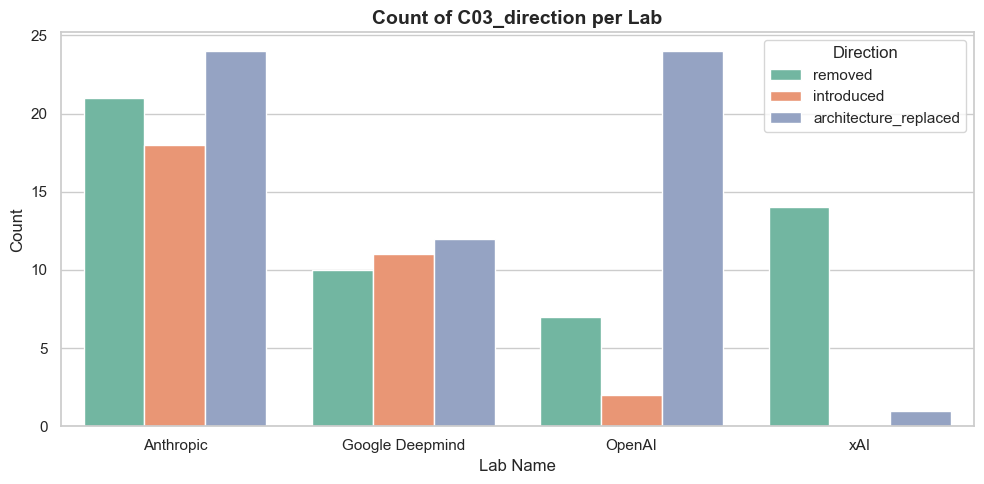

In [28]:
# Updated LAB_ORDER using full lab names
LAB_ORDER = ["Anthropic", "Google Deepmind", "OpenAI", "xAI"]

# Filter for C03_direction architectural changes
c03_filtered = file3[file3["C03_direction"].isin(["architecture_replaced", "introduced", "removed"])].copy()

plt.figure(figsize=(10, 5))
sns.countplot(
    data=c03_filtered,
    x="lab_names",
    hue="C03_direction",
    order=LAB_ORDER,
    palette="Set2"
)
plt.title("Count of C03_direction per Lab", fontsize=14, fontweight="bold")
plt.xlabel("Lab Name", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.legend(title="Direction")
plt.tight_layout()
plt.show()

#### * Graph 2: C04_direction per Lab (loosening vs tightening)

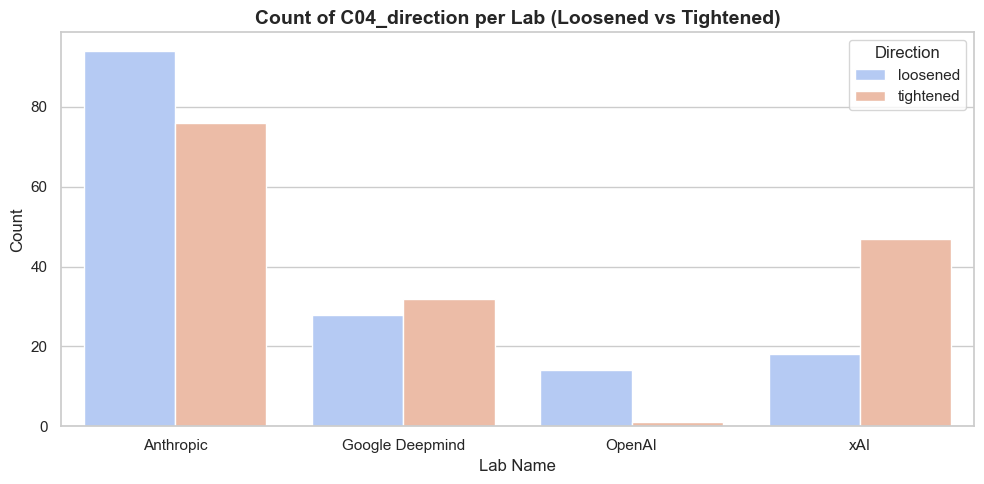

In [323]:
# Updated LAB_ORDER using full lab names
LAB_ORDER = ["Anthropic", "Google Deepmind", "OpenAI", "xAI"]

# Filter for C04_direction loosened and tightened entries
c04_filtered = file3[file3["C04_direction"].isin(["loosened", "tightened"])].copy()

plt.figure(figsize=(10, 5))
sns.countplot(
    data=c04_filtered,
    x="lab_names",
    hue="C04_direction",
    order=LAB_ORDER,
    palette="coolwarm"
)
plt.title("Count of C04_direction per Lab (Loosened vs Tightened)", fontsize=14, fontweight="bold")
plt.xlabel("Lab Name", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.legend(title="Direction")
plt.tight_layout()
plt.show()

In [345]:
# Is the loosening trend lab conditional?
from scipy.stats import chi2_contingency

c04_valid = file3[file3["C04_direction"].isin(["loosened", "tightened"])].copy()

contingency = pd.crosstab(c04_valid["lab_names"], c04_valid["C04_direction"])
print(contingency)

chi2, p, dof, expected = chi2_contingency(contingency)
print(f"\nChi2 = {chi2:.3f}, dof = {dof}, p = {p:.4f}")
print("Expected counts:\n", pd.DataFrame(expected, index=contingency.index, columns=contingency.columns))

C04_direction    loosened  tightened
lab_names                           
Anthropic              94         76
Google Deepmind        28         32
OpenAI                 14          1
xAI                    18         47

Chi2 = 26.366, dof = 3, p = 0.0000
Expected counts:
 C04_direction     loosened  tightened
lab_names                            
Anthropic        84.451613  85.548387
Google Deepmind  29.806452  30.193548
OpenAI            7.451613   7.548387
xAI              32.290323  32.709677


In [347]:
from scipy.stats import fisher_exact

# OpenAI 2025 (14 loosened, 1 tightened) vs xAI-RMF 2025 (6 loosened, 20 tightened)
table = [[14, 1], [6, 20]]
odds_ratio, p = fisher_exact(table)
print(f"Odds ratio: {odds_ratio:.3f}, p = {p:.4f}")

Odds ratio: 46.667, p = 0.0000


In [349]:
# 1. Filter data for non-cumulative transitions and relevant C04 directions
filtered_df = file3[
    (file3["cumulative"] == False) & 
    (file3["C04_direction"].isin(["loosened", "tightened"]))
].copy()

# Clean missing years to avoid blank/NaN rows
filtered_df["year_derived"] = filtered_df["year_derived"].fillna("Unknown").astype(str)

# 2. Group by Year and Lab to aggregate counts
yearly_lab_pivot = (
    pd.crosstab(
        index=[filtered_df["year_derived"], filtered_df["unit_id_labs"]],
        columns=filtered_df["C04_direction"]
    )
    .reindex(columns=["loosened", "tightened"], fill_value=0)
)

# 3. Add row-level totals (Total = Loosened + Tightened)
yearly_lab_pivot["total"] = yearly_lab_pivot["loosened"] + yearly_lab_pivot["tightened"]

# 4. Display formatted table
print("=== C04 Direction Breakdown by Year and Lab (cumulative == FALSE) ===")
print(yearly_lab_pivot)

=== C04 Direction Breakdown by Year and Lab (cumulative == FALSE) ===
C04_direction              loosened  tightened  total
year_derived unit_id_labs                            
2023         OAI-PF              14          1     15
2024         ANT-RSP             18          9     27
             GDM-FSF              8          3     11
2025         ANT-RSP             47         52     99
             GDM-FSF             13         24     37
             XAI-FAIF             2          2      4
             XAI-RMF              6         20     26
2026         ANT-RSP             12          4     16
             XAI-FAIF             5          6     11


/var/folders/mp/r__mfhrd2310ndf7csqx3kyh0000gn/T/ipykernel_72128/1237084638.py:8: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  filtered_df["year_derived"] = filtered_df["year_derived"].fillna("Unknown").astype(str)


In [351]:
# 1. Filter for non-cumulative entries and relevant directions
c04_facet_df = file3[
    (file3["cumulative"] == False) & 
    (file3["C04_direction"].isin(["loosened", "tightened"]))
].copy()

# 2. Clean C04_facet column to explicitly show 'NA' for missing values
c04_facet_df["C04_facet_clean"] = c04_facet_df["C04_facet"].fillna("NA").astype(str)

# 3. Cross-tabulate counts across C04_facet categories
facet_counts = pd.crosstab(
    c04_facet_df["C04_facet_clean"], 
    c04_facet_df["C04_direction"]
).reindex(columns=["loosened", "tightened"], fill_value=0)

# 4. Build summary table with total and loosening percentage
facet_summary = pd.DataFrame(index=facet_counts.index)
facet_summary["Loosened Count"] = facet_counts["loosened"]
facet_summary["Tightened Count"] = facet_counts["tightened"]
facet_summary["Total"] = facet_summary["Loosened Count"] + facet_summary["Tightened Count"]

# Calculate loosening percentage (Loosened / Total * 100)
facet_summary["Loosening (%)"] = (
    (facet_summary["Loosened Count"] / facet_summary["Total"]) * 100
).round(2)

# 5. Add Total Row
total_l = facet_summary["Loosened Count"].sum()
total_t = facet_summary["Tightened Count"].sum()
grand_total = total_l + total_t

total_row = pd.DataFrame({
    "Loosened Count": total_l,
    "Tightened Count": total_t,
    "Total": grand_total,
    "Loosening (%)": round((total_l / grand_total * 100), 2) if grand_total > 0 else 0.0
}, index=["Total"])

facet_summary_final = pd.concat([facet_summary, total_row])

print("=== C04_facet Breakdown (Loosening vs Tightening & Loosening %) ===")
print(facet_summary_final.to_string())

=== C04_facet Breakdown (Loosening vs Tightening & Loosening %) ===
          Loosened Count  Tightened Count  Total  Loosening (%)
NA                    40               34     74          54.05
bar                   16                5     21          76.19
both                   2                2      4          50.00
modality              67               80    147          45.58
Total                125              121    246          50.81


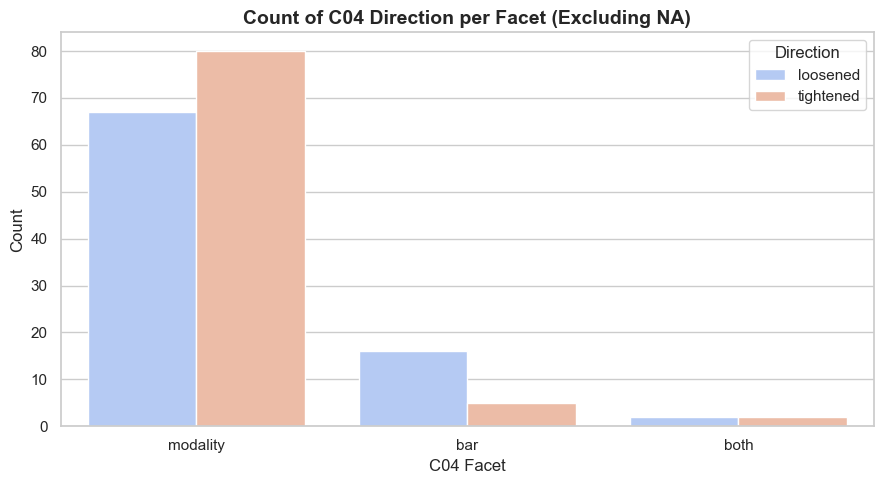

In [355]:
# 1. Filter for non-cumulative entries, relevant directions, and drop NA facets
chart_df = file3[
    (file3["cumulative"] == False) & 
    (file3["C04_direction"].isin(["loosened", "tightened"])) & 
    (file3["C04_facet"].notna()) & 
    (file3["C04_facet"].astype(str).str.upper() != "NA")
].copy()

# 2. Plot Bar Chart
plt.figure(figsize=(9, 5))
sns.countplot(
    data=chart_df,
    x="C04_facet",
    hue="C04_direction",
    palette="coolwarm"
)

plt.title("Count of C04 Direction per Facet (Excluding NA)", fontsize=14, fontweight="bold")
plt.xlabel("C04 Facet", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.legend(title="Direction")
plt.tight_layout()

plt.show()

In [357]:
# Hypthosis testing

facet_valid = file3[
    file3["C04_direction"].isin(["loosened", "tightened"]) &
    file3["C04_facet"].isin(["bar", "modality"])  # drop 'both'/'unassigned' for a clean 2x2, or keep all facets for the full table
].copy()

facet_table = pd.crosstab(facet_valid["C04_facet"], facet_valid["C04_direction"])
print(facet_table)

chi2, p, dof, expected = chi2_contingency(facet_table)
print(f"\nChi2 = {chi2:.3f}, dof = {dof}, p = {p:.4f}")

# Effect size (Cramér's V) since chi-square p-value alone won't tell you how big the swap is
n = facet_table.sum().sum()
cramers_v = (chi2 / (n * (min(facet_table.shape) - 1))) ** 0.5
print(f"Cramér's V: {cramers_v:.3f}")

C04_direction  loosened  tightened
C04_facet                         
bar                  17          6
modality             82        102

Chi2 = 5.930, dof = 1, p = 0.0149
Cramér's V: 0.169


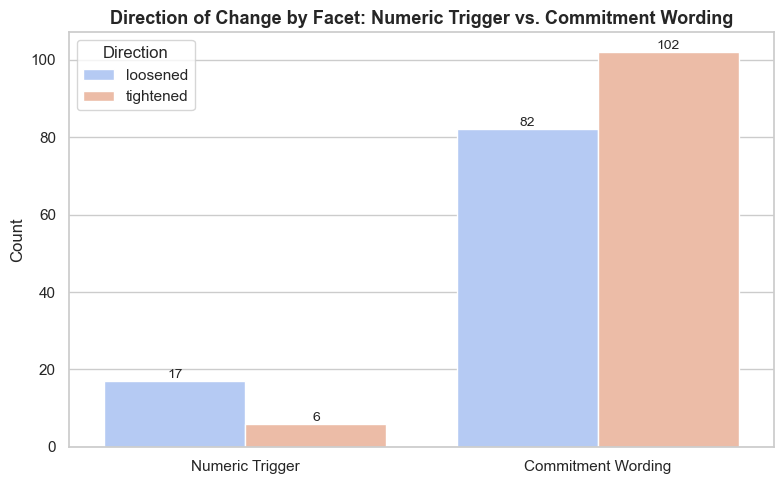

In [31]:
facet_valid = file3[
    file3["C04_direction"].isin(["loosened", "tightened"]) &
    file3["C04_facet"].isin(["bar", "modality"])
].copy()

facet_label_map = {"bar": "Numeric Trigger", "modality": "Commitment Wording"}
facet_valid["Facet"] = facet_valid["C04_facet"].map(facet_label_map)

plt.figure(figsize=(8, 5))
ax = sns.countplot(
    data=facet_valid,
    x="Facet",
    hue="C04_direction",
    order=["Numeric Trigger", "Commitment Wording"],
    hue_order=["loosened", "tightened"],
    palette="coolwarm"
)

for container in ax.containers:
    ax.bar_label(container, fontsize=10)

plt.title("Direction of Change by Facet: Numeric Trigger vs. Commitment Wording", fontsize=13, fontweight="bold")
plt.xlabel("")
plt.ylabel("Count")
plt.legend(title="Direction")
plt.tight_layout()
plt.savefig("figure_facet_split.png", dpi=300)
plt.show()